<a href="https://colab.research.google.com/github/kjfcvx12/Colab/blob/main/05_27_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ffmpeg
!pip install -q pydub

In [2]:
# 음성인식 모델
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import torchaudio
import IPython.display as ipd # 주피터/ 코랩에서 오디오 재생하려고
from tqdm.notebook import tqdm
from torchaudio.datasets import SPEECHCOMMANDS # 구글에서 제공하는 음성 데이터 셋
import os

In [3]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [4]:
# SPEECHCOMMANDS 데이터셋을 상속함
class Speech(SPEECHCOMMANDS):
  def __init__(self, subset:str=None):
    # 부모 클래스를 호출하여 데이터셋 다운로드함
    super().__init__("./",download=True)

    def load_list(filename):
      # 파일 경로 설정함
      filepath=os.path.join(self._path, filename)
      # 파일을 열어서 각가 줄에 있는 파일 경로를 리스트로 변환함
      with open(filepath) as fileobj:
        return [os.path.normpath(os.path.join(self._path, line.strip())) for line in fileobj]

    # 검증용 데이터셋 로드할 경우
    if subset =='validation':
      self._walker=load_list("validation_list.txt")

    elif subset == 'testing':
      self._walker=load_list("testing_list.txt")

    elif subset == 'training':
      # 검증, 테스트에 사용될 파일 경로 먼저 모은 후에 set으로 중복제거함 -> 검색 속도 최적화하기 위해
      excludes=load_list("validation_list.txt")+load_list("testing_list.txt")
      # -> 검색 속도 최적화하기 위해
      excludes=set(excludes)

      # 학습용 데이터는 검증, 테스트 데이터에 포함되지 않은 파일들로 구성하려고
      # 학습/ 평가용 데이터 중복 원천 차단
      self._walker=[w for w in self._walker if w not in excludes]

# 학습, 테스트 데이터 생성
train_set=Speech("training")
test_set=Speech("testing")

# return waveform, sample_rate, label, speaker_id, utterance_number

# 파형데이터, 초당 생플링 횟수, 말한 단어, 화자 식별값, 같은 단어 여러번 말했을 때 순서번호
waveform, sample_rate, label, speaker_id, utterance_number=train_set[0]

waveform, sample_rate, label, speaker_id, utterance_number



100%|██████████| 2.26G/2.26G [00:31<00:00, 76.1MB/s]


(tensor([[-0.0658, -0.0709, -0.0753,  ..., -0.0700, -0.0731, -0.0704]]),
 16000,
 'backward',
 '0165e0e8',
 0)

Text(0.5, 1.0, 'backward')

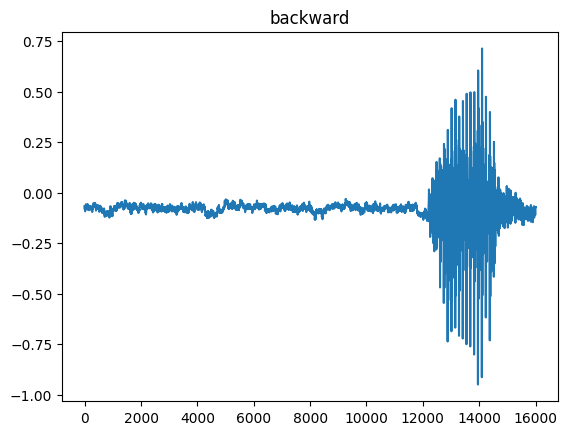

In [5]:
# waveform (16000,1) -> (채널, 시간 :1,16000)
plt.plot(waveform.t().numpy())
plt.title(label)

In [6]:
len(train_set), len(test_set)

(84843, 11005)

In [7]:
labels=sorted(list(i[2] for i in train_set))
labels

['backward',
 'backward',
 'backward',
 'backward',
 'backward',
 'backward',
 'backward',
 'backward',
 'backward',
 'backward',
 'backward',
 'backward',
 'backward',
 'backward',
 'backward',
 'backward',
 'backward',
 'backward',
 'backward',
 'backward',
 'backward',
 'backward',
 'backward',
 'backward',
 'backward',
 'backward',
 'backward',
 'backward',
 'backward',
 'backward',
 'backward',
 'backward',
 'backward',
 'backward',
 'backward',
 'backward',
 'backward',
 'backward',
 'backward',
 'backward',
 'backward',
 'backward',
 'backward',
 'backward',
 'backward',
 'backward',
 'backward',
 'backward',
 'backward',
 'backward',
 'backward',
 'backward',
 'backward',
 'backward',
 'backward',
 'backward',
 'backward',
 'backward',
 'backward',
 'backward',
 'backward',
 'backward',
 'backward',
 'backward',
 'backward',
 'backward',
 'backward',
 'backward',
 'backward',
 'backward',
 'backward',
 'backward',
 'backward',
 'backward',
 'backward',
 'backward',
 'backward',

In [8]:
from collections import Counter
print(len(Counter(labels)))
# 데이터셋에 총 몇개 클래스가 있는지 알려줌 -> 단어가 몇개 들어있는지 출력됨
print(Counter(labels))

35
Counter({'zero': 3250, 'five': 3240, 'yes': 3228, 'seven': 3205, 'nine': 3170, 'one': 3140, 'down': 3134, 'no': 3130, 'stop': 3111, 'two': 3111, 'go': 3106, 'six': 3088, 'on': 3086, 'left': 3037, 'eight': 3033, 'right': 3019, 'off': 2970, 'three': 2966, 'four': 2955, 'up': 2948, 'house': 1727, 'wow': 1724, 'dog': 1711, 'marvin': 1710, 'bird': 1697, 'cat': 1657, 'happy': 1632, 'sheila': 1606, 'bed': 1594, 'tree': 1407, 'backward': 1346, 'visual': 1288, 'learn': 1286, 'follow': 1275, 'forward': 1256})


In [9]:
waveform_first, sample_rate, label, *_=train_set[0]
print(label)
ipd.Audio(waveform_first.numpy(), rate=sample_rate)

backward


In [10]:
waveform_second, sample_rate, label, *_=train_set[1]
print(label)
ipd.Audio(waveform_second.numpy(), rate=sample_rate)

backward


In [11]:
# 1초를 몇개로 쪼개서 기록했냐
# 숫자가 작을수록 1초당 기록하는 정보량이 줄어듬 -> 음질이 떨어짐 -> 모델 처리해야할 데이터양도 줄어듬
new_sample_rate=8000

# 16000 -> 8000 으로 리샘플링하는 변환 설정
transform=torchaudio.transforms.Resample(orig_freq=sample_rate, new_freq=new_sample_rate)

# 리샘플링 규칙을 실제데이터에 적용시킴 -> 8000Hz 적용하여 변환된 파형 생성
transformed=transform(waveform_second)

ipd.Audio(transformed.numpy(), rate=new_sample_rate)

In [12]:
# 샘플링 속도 다를 수 있기 때문에 학습전에 모든 데이터를 똑같은 속도로 통일 시켜야함(중요한 전처리)

In [13]:
print(labels.index('backward'))
print(labels.index('yes'))
print(labels.index('zero'))

0
78365
81593


In [14]:
# 단어 index -> tensor로 변환
def label_to_index(word):
  # 라벨 리스트에서 단어가 몇번째에 있는지 찾아서 텐서형식으로 변환
  return torch.tensor(labels.index(word))

def index_to_label(index):
  # 숫자(인덱스) 입력하면 원래 어떤 단어였는지 알려줌
  return labels[index]

word="yes"
index=label_to_index(word)

print(word, index.numpy(), index_to_label(index))

yes 78365 yes


In [15]:
# 오디오 데이터셋 -> 일괄적으로 반복할 수 있는 함수 구현
a=torch.ones(15,300)
b=torch.ones(20,300)
c=torch.ones(5,300)

# 텐서들을 합쳐서 [배치크기, 시간길이(행), 특징크기(열)] 로 만듬 (b의 길이에 맞춰 a,c의 빈 공간 0으로 채움)
# [3, 20, 300]
padded=torch.nn.utils.rnn.pad_sequence([a,b,c], batch_first=True, padding_value=0.)

print(padded.size())

torch.Size([3, 20, 300])


In [16]:
def pad_sequence(batch):
    # 0으로 패딩하여 배치 내의 모든 텐서를 동일한 길이
    # 녹음 길이 다 다르므로 길이 맞춤
    # 음성데이터 원본 [채널, 시간] => [시간, 채널]
    batch = [item.t() for item in batch]
    batch = torch.nn.utils.rnn.pad_sequence(batch, batch_first=True, padding_value=0.)  # 0으로 패딩하여 시퀀스 길이 맞춤
    return batch.permute(0, 2, 1) # cnn 규격으로 맞추기 위해 [배치, 채널, 시간]

# 여러개의 오디오 파일을 하나의 텐서로 묶어
def collate_fn(batch):

    tensors, targets = [], []

    # 리스트로 데이터를 모으고, 레이블을 인덱스로 인코딩
    for waveform, _, label, *_ in batch:
        tensors += [waveform]  # 파형
        targets += [label_to_index(label)]  # 레이블을 인덱스로 변환하여 수집

    # 텐서 리스트를 배치 텐서로 그룹화
    tensors = pad_sequence(tensors)
    targets = torch.stack(targets)

    return tensors, targets

batch_size = 256  # 배치 크기 설정

if device == "cuda":
  # gpu -> 1이상으로 설정
    num_workers = 1
    # gpu메모리 데이터 옮길 때 빠르게 전송되도록 고정(pin) 시키는 옵션
    pin_memory = True
else:
    num_workers = 0
    pin_memory = False

# 학습 데이터 로더 설정
train_loader = torch.utils.data.DataLoader(
    train_set,
    batch_size=batch_size,  # 배치 크기 설정
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=num_workers,
    pin_memory=pin_memory,
)

# 테스트 데이터 로더 설정
test_loader = torch.utils.data.DataLoader(
    test_set,
    batch_size=batch_size,  # 배치 크기 설정
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=num_workers,
    pin_memory=pin_memory,
)

In [17]:
class M5(nn.Module):
    def __init__(self, n_input=1, n_output=35, stride=16, n_channel=32):

        """
         n_input=1 입력 채널 수: 모노 1, 스트레오(좌,우) 신호 2
         n_output=35 출력 레이어의 출력 차원, 즉 클래스의 개수
         stride=16 커널이 한 번 적용된 후 16개의 타임스텝을 건너뛰어 다음 위치에 적용, 계산량 줄이는 데 도움
         n_channel=32 각 컨볼루션 레이어의 출력 채널 수
        """
        super().__init__()
        # 오디오는 보통 conv1d
        self.conv1 = nn.Conv1d(n_input, n_channel, kernel_size=80, stride=stride)
        self.bn1 = nn.BatchNorm1d(n_channel)
        self.pool1 = nn.MaxPool1d(4) # 소리의 가장 중요한 특징만 남기고 크기를 1/4로 줄임
        # 차원축소해서 계산량 줄임
        self.conv2 = nn.Conv1d(n_channel, n_channel, kernel_size=3)
        self.bn2 = nn.BatchNorm1d(n_channel)
        self.pool2 = nn.MaxPool1d(4)
        self.conv3 = nn.Conv1d(n_channel, 2 * n_channel, kernel_size=3)
        self.bn3 = nn.BatchNorm1d(2 * n_channel)
        self.pool3 = nn.MaxPool1d(4)
        self.conv4 = nn.Conv1d(2 * n_channel, 2 * n_channel, kernel_size=3)
        self.bn4 = nn.BatchNorm1d(2 * n_channel)
        self.pool4 = nn.MaxPool1d(4)
        self.fc1 = nn.Linear(2 * n_channel, n_output)

    def forward(self, x):
        x = self.conv1(x)
        x = F.relu(self.bn1(x))
        x = self.pool1(x)
        x = self.conv2(x)
        x = F.relu(self.bn2(x))
        x = self.pool2(x)
        x = self.conv3(x)
        x = F.relu(self.bn3(x))
        x = self.pool3(x)
        x = self.conv4(x)
        x = F.relu(self.bn4(x))
        x = self.pool4(x)
        # 마지막에 남은 특징들 평균냄 -> 전체적인 특징 뽑아냄
        x = F.avg_pool1d(x, x.shape[-1]) # 남아있는 전체 시간 길이
        x = x.permute(0, 2, 1) # 모델 마지막 - Linear 는 [배치, 채널]을 원함-> 채널 맨 마지막에 넣어야함 - ([배치, 채널, 시간]) -> (배치, 시간, 채널)
        x = self.fc1(x)
        return F.log_softmax(x, dim=2)

model = M5(n_input=transformed.shape[0], n_output=len(labels))
model.to(device)
print(model)

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

n = count_parameters(model)
print(f"Number of parameters: {n:,}")

M5(
  (conv1): Conv1d(1, 32, kernel_size=(80,), stride=(16,))
  (bn1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool1d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv1d(32, 32, kernel_size=(3,), stride=(1,))
  (bn2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool1d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv1d(32, 64, kernel_size=(3,), stride=(1,))
  (bn3): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool3): MaxPool1d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
  (conv4): Conv1d(64, 64, kernel_size=(3,), stride=(1,))
  (bn4): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool4): MaxPool1d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=64, out_features=84843, bias=True)
)
Nu

In [18]:
# 모델이 너무 복잡하게 학습하는 거 막음 -> 가중치들이 너무 큰 값 갖지 않도록 억제 -> 과적합 방지
optimizer=optim.Adam(model.parameters(), lr=0.01, weight_decay=0.0001)

In [19]:
# 20에폭마다 학습률을 0.1배로 줄여라
# 0~19에폭에서는 0.01로 합습시키다가 20에폭부터는 0.001 줄임
# 정답 방향 찾기가 좀 수월 -> StepLR (보폭 줄여줌 -> 미세한 특징들까지 학습해 정확도 최대치로 끌러올리마)
scheduler=optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.1)

In [20]:
def train(model, epoch, log_interval):
    model.train()  # 모델을 학습 모드로 설정
    for batch_idx, (data, target) in enumerate(train_loader):

        data = data.to(device)
        target = target.to(device)


        data = transform(data)
        output = model(data)

        loss = F.nll_loss(output.squeeze(), target)

        optimizer.zero_grad()  # 이전에 계산된 변화도를 모두 초기화
        loss.backward()  # 손실에 대한 역전파 수행
        optimizer.step()  # 가중치 업데이트


        if batch_idx % log_interval == 0:
            print(f"Train Epoch: {epoch} [{batch_idx * len(data)}/{len(train_loader.dataset)} \
            ({100. * batch_idx / len(train_loader):.0f}%)]\tLoss: {loss.item():.6f}")


        pbar.update(pbar_update)
        losses.append(loss.item())

In [21]:
# 몇 개 맞혔는지 확인
def number_of_correct(pred, target):
    return pred.squeeze().eq(target).sum().item()

# [yes : 0.8, no : 0.1.......]
def get_likely_index(tensor):
  # 확률이 가장 높은 단어 선택
    return tensor.argmax(dim=-1)

def test(model, epoch):
    model.eval()  # 모델을 평가 모드로 설정
    correct = 0  # 정확한 예측 수를 저장할 변수

    with torch.inference_mode():
        for data, target in test_loader:

            data = data.to(device)
            target = target.to(device)


            data = transform(data)
            output = model(data)

            pred = get_likely_index(output)  # 가장 가능성 높은 예측값을 가져옴
            correct += number_of_correct(pred, target)  # 정확한 예측 개수를 업데이트

In [22]:
# 데이터 시스템
# model (M5 class)
# optimer, scheduler 설정함
# train. test

  0%|          | 0/2 [00:00<?, ?it/s]

Train Epoch: 1 [0/84843             (0%)]	Loss: 11.696860
Train Epoch: 1 [5120/84843             (6%)]	Loss: 3.352388
Train Epoch: 1 [10240/84843             (12%)]	Loss: 2.726777
Train Epoch: 1 [15360/84843             (18%)]	Loss: 2.544228
Train Epoch: 1 [20480/84843             (24%)]	Loss: 2.218404
Train Epoch: 1 [25600/84843             (30%)]	Loss: 2.123890
Train Epoch: 1 [30720/84843             (36%)]	Loss: 2.239661
Train Epoch: 1 [35840/84843             (42%)]	Loss: 1.879908
Train Epoch: 1 [40960/84843             (48%)]	Loss: 1.619291
Train Epoch: 1 [46080/84843             (54%)]	Loss: 1.534112
Train Epoch: 1 [51200/84843             (60%)]	Loss: 1.742205
Train Epoch: 1 [56320/84843             (66%)]	Loss: 1.604365
Train Epoch: 1 [61440/84843             (72%)]	Loss: 1.320036
Train Epoch: 1 [66560/84843             (78%)]	Loss: 1.218880
Train Epoch: 1 [71680/84843             (84%)]	Loss: 1.170596
Train Epoch: 1 [76800/84843             (90%)]	Loss: 1.075805
Train Epoch: 1

Text(0.5, 1.0, 'training loss')

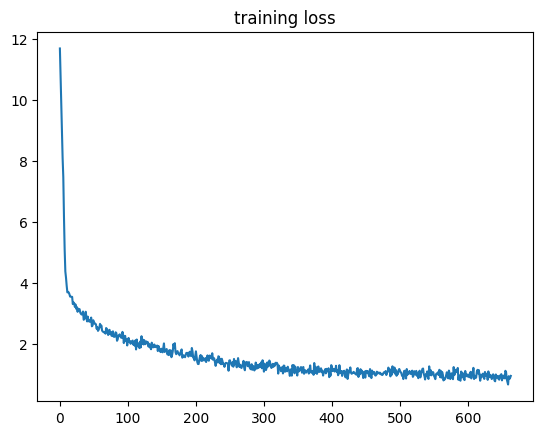

In [23]:
log_interval = 20
n_epoch = 2

pbar_update = 1 / (len(train_loader) + len(test_loader))
losses = []  # 손실 값을 저장할 리스트

transform = transform.to(device)


with tqdm(total=n_epoch) as pbar:
    for epoch in range(1, n_epoch + 1):
        train(model, epoch, log_interval)  # 각 에포크마다 학습 함수 호출
        test(model, epoch)  # 각 에포크마다 테스트 함수 호출
        scheduler.step()  # 스케줄러 업데이트 (학습률 조정)


plt.plot(losses)
plt.title("training loss")